## GRF Variance and Estimators
Julian Hsu

Date Created: 2026-06-17

In [1]:
import numpy as np
import pandas as pd

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from econml.grf import CausalForest

## DGP and Estimation Functions

DGP with placebo effect.

In [3]:
def dgp(N=None, K =None):
    X = np.random.normal(size=(N, K))
    W = np.random.choice([0, 1], size=N)
    ## Y is linear in X
    y = np.dot(X, np.random.normal(size=K)) + W * 0 + np.random.normal(size=N)

    ## Okay now make Y also non-linear in X for fun
    y += np.sin(np.dot( np.abs(X), np.random.uniform(-1,0,size=K))) 

    y += np.sin(np.dot( np.exp(X/1000), np.random.uniform(0.5,1.0,size=K))) 


    output_df = pd.DataFrame(X, columns=[f'X{i}' for i in range(K)])
    output_df['W'] = W
    output_df['y'] = y

    return output_df

In [4]:
def estimate_hte_ci(data, n_estimators_here, X_cols, W_col, y_col):
    est = CausalForest(n_estimators=n_estimators_here, n_jobs=-1)
    est.fit(data[X_cols].values, data[W_col].values, data[y_col].values)
    ci95_output =  est.predict_interval(data[X_cols].values)
    point_estimate = est.predict(data[X_cols].values)
    return {'point_estimate': point_estimate, 'ci95_lower': ci95_output[0], 'ci95_upper': ci95_output[1]}

def plot_hte_ci(hte_ci_output,display_plot=False):
    ## Order values in ascending order of the point estimate and plot that way
    data = pd.DataFrame(data={'point_estimate': hte_ci_output['point_estimate'].flatten()
                              , 'ci95_lower': hte_ci_output['ci95_lower'].flatten()
                              , 'ci95_upper': hte_ci_output['ci95_upper'].flatten()})
    data.sort_values(by='point_estimate', inplace=True)

    if display_plot == True:

        plt.figure(figsize=(10,6))
        plt.scatter(np.arange(len(data)), data['point_estimate'], label='Point Estimate', color='blue')
        plt.fill_between(np.arange(len(data)), data['ci95_lower'], data['ci95_upper'], color='blue', alpha=0.2, label='95% CI')
        plt.plot(np.arange(len(data)), np.zeros(len(data)), color='black', linestyle='--')
        plt.xlabel('Index')
        plt.ylabel('HTE')
        plt.legend()
        plt.show()
    else:
        pass
    
    ## Calculate statistical sig
    data['statsig'] = (data['ci95_lower'] > 0 ) | (data['ci95_upper'] < 0)
    return data['statsig']


    

In [5]:
def estimate_hte_ci_grf(data, n_estimators_here, X_cols, W_col, y_col):
    est = GRFCausalForest(n_trees=n_estimators_here)
    # Our GRF fit signature: fit(X, Y, W)
    est.fit(data[X_cols].values, data[y_col].values, data[W_col].values)
    tau, lower, upper = est.predict_interval(data[X_cols].values)
    return {'point_estimate': tau, 'ci95_lower': lower, 'ci95_upper': upper}

In [6]:
## Unit test
xd = dgp(N=1000, K=10)

# econml CausalForest
hte_pout = estimate_hte_ci(xd, n_estimators_here=100, X_cols=[f'X{i}' for i in range(10)], W_col='W', y_col='y')
a = plot_hte_ci(hte_pout, display_plot=False)
print('econml GRF | Prop stat sig = {0:5.2f}%'.format(a.mean()*100))


econml GRF | Prop stat sig =  5.30%


## Simulations
Iterate over the number of sample size and number of estimators

In [ ]:
sample_size_list = [100, 500]
n_esimators_list = [ 40, 100, 400, 4000]
baseline_sim = 200
K_dim = 2
df_sim = pd.DataFrame()
i = 0
for sample_size in sample_size_list:
    for n_estimators in n_esimators_list:
        for s in range(baseline_sim):
            xd = dgp(N=sample_size, K=K_dim)
            hte_pout = estimate_hte_ci(xd, n_estimators_here=n_estimators, X_cols=[f'X{i}' for i in range(K_dim)], W_col='W', y_col='y')
            a=plot_hte_ci(hte_pout, display_plot=False)

            df_entry = pd.DataFrame(index=[i], data={'sample_size': sample_size, 'n_estimators': n_estimators, 'prop_stat_sig': a.mean()})
            i+=1

            df_sim = pd.concat([df_sim, df_entry], ignore_index=True)

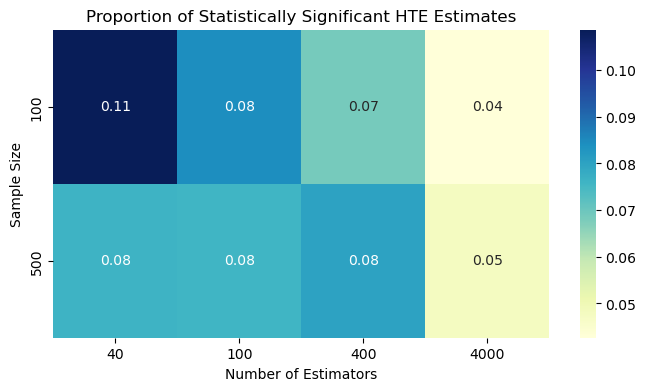

In [ ]:
## Create a heatmap of the results over sample size and estimators
pivot_table = df_sim.groupby(['sample_size', 'n_estimators'])['prop_stat_sig'].mean().unstack()
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Proportion of Statistically Significant HTE Estimates')
plt.xlabel('Number of Estimators')
plt.ylabel('Sample Size')
plt.show()


**Takeaway**
To do proper inference for GRF, you do need all those trees. To reduce computational load, I almost always pull a random subset for offline analysis. A common one is to do heterogeneous treatment effect modeling with generalized random forests (GRF). 

With the mindset of getting results quickly without overclocking all the servers, I never set my number of trees in the GRF (n_estimators) over 200. 

Turns out this decision cost me dearly. I show with simulation data (notebook here: ) that when a GRF with fewer than 4K trees (n_estimators = 4000) is trained on a placebo treatment, there are too many false positives. It should be that only 5% of the HTEs are stat sig, but instead I get X% when using the default value (n_estimators=100)!

Why is this? Imagine that you trained a GRF on just one tree. Your standard error is obviously wrong because you only learned one tree of data. In fact, your standard error will be too small because you haven't taken account how the estimates would change if you ran even more trees. In other words, the variance of the HTE estimates is based on the actual variance and that from this specific set of trees.


This isn't entirely a surprise - the GRF package recommends having a lot of trees for this reason: https://grf-labs.github.io/grf/reference/predict.causal_forest.html. But I was surprised by how many trees I would need, even with a sample size of 100!

TLDR - someone at Amazon and Airbnb please re-run all my analyses with n_estimators = (a lot). Thanks!


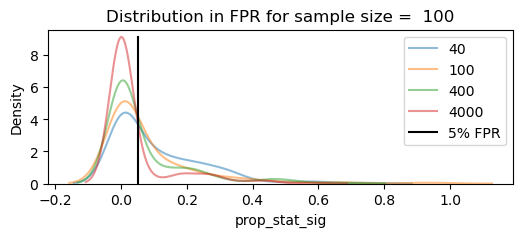

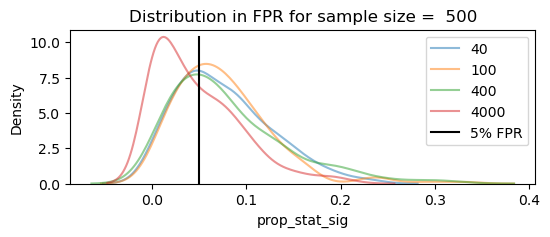

In [ ]:
## Also show the histogram for each of the number of estimators.

for ss_plot in sample_size_list: 

    fig,ax = plt.subplots(figsize=(6,2))
    for r in n_esimators_list:
        plor = df_sim.loc[(df_sim.sample_size==ss_plot) & (df_sim.n_estimators==r)]
        # ax.hist(plor['prop_stat_sig'], alpha=0.20,  label=r)
        sns.kdeplot(data=plor, x="prop_stat_sig", alpha=0.50, label=r)
    ax.plot([0.05, 0.05 ], [0, ax.get_ylim()[1]*0.95 ], color='black', label='5% FPR')
    ax.legend()
    ax.set_title('Distribution in FPR for sample size ={0:5.0f}'.format(ss_plot))
    plt.show()
